In [71]:
import os
import re
import sys
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

OUTPUT_DIR = "hasil_clustering"

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR)

print("Setup selesai. Output folder:", os.path.abspath(OUTPUT_DIR))

Setup selesai. Output folder: c:\Users\andika\Projects\clustering-judul-skripsi\hasil_clustering


In [ ]:
print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: c:\Program Files\Python314\python.exe
Torch: 2.10.0+cu126
CUDA available: True


In [73]:
df = pd.read_csv("dataset_titles.csv")
print(f"Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print("Kolom:", df.columns.tolist())
df.head(3)

Dataset: 792 baris, 8 kolom
Kolom: ['id', 'title', 'category', 'year', 'author', 'advisor', 'url', 'abstract']


,id,title,category,year,author,advisor,url,abstract
0,1,Alarm Limitasi Pengunjung untuk Ruang Umum Ter...,Teknik Informatika,2021,Angelica Kirana Sandra Dewi,"Martin C.T. Manullang, S.T., M.T.",https://repo.itera.ac.id/depan/submission/SB21...,Dengan mulai kembali pulihnya perekenomian di ...
1,2,ALAT DETEKSI DAN PENGUSIRAN HAMA TIKUS DAN BUR...,Teknik Informatika,2021,Indri Wulan Dari,"Meida Cahyo Untoro, S.Kom.,M.Kom.",https://repo.itera.ac.id/depan/submission/SB22...,Alat Deteksi dan Pengusiran Hama Tikus dan Bur...
2,3,Alat Monitoring Tanah dan Pengusir Hama Otomat...,Teknik Informatika,2021,Leo Viranda Millennium,"Meida Cahyo Untoro, S.Kom., M.Kom.",https://repo.itera.ac.id/depan/submission/SB21...,Padi dalam pertumbuhannya memerlukan kondisi l...


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def prepare_text(row):
    title = str(row['title']) if pd.notna(row['title']) else ''
    abstract = str(row['abstract']) if pd.notna(row['abstract']) else ''
    return re.sub(r'\s+', ' ', title + ' ' + abstract).strip()

df['clean_title'] = df['title'].apply(lambda x: clean_text(str(x)) if pd.notna(x) else '')
df['text'] = df.apply(prepare_text, axis=1)
texts = df['text'].tolist()

print(f"Jumlah teks: {len(texts)}")
print("Contoh teks pertama:")
print(texts[0][:300])

Jumlah teks: 792
Contoh teks pertama:
Alarm Limitasi Pengunjung untuk Ruang Umum Tertutup Berbasis Crowd Counting Dengan mulai kembali pulihnya perekenomian di masa pandemik Covid-19 ini, aktifitas ekonomi kini kembali berjalan lagi. Sektor bisnis dan perdagangan pun mulai dibuka kembali. Dengan dibukanya sektor tersebut, dikhawatirkan 


In [ ]:
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
device = "cuda"
print(f"Device: {device}")

st_model = SentenceTransformer(MODEL_NAME, device=device)
print(f"Model '{MODEL_NAME}' berhasil dimuat.")

Device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13879.42it/s]
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2' berhasil dimuat.


In [76]:
# SentenceTransformer.encode() sudah menangani pooling secara optimal.
# normalize_embeddings=True melakukan L2 normalization sehingga Euclidean K-Means
# setara dengan cosine K-Means — ini krusial agar silhouette tidak selalu memilih K=2.
print("Membuat embeddings...")
embeddings = st_model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)
print(f"\nShape embeddings: {embeddings.shape}")

np.save(os.path.join(OUTPUT_DIR, "embeddings.npy"), embeddings)
print(f"Embeddings disimpan ke {OUTPUT_DIR}/embeddings.npy")

Membuat embeddings...


Batches: 100%|██████████| 25/25 [01:47<00:00,  4.32s/it]


Shape embeddings: (792, 768)
Embeddings disimpan ke hasil_clustering/embeddings.npy


In [77]:
# Reduksi dimensi dengan PCA sebelum clustering (mengatasi curse of dimensionality)
N_COMPONENTS = 50

pca_pre = PCA(n_components=N_COMPONENTS, random_state=42)
embeddings_pca = pca_pre.fit_transform(embeddings)

variance_explained = pca_pre.explained_variance_ratio_.sum() * 100
print(f"PCA: {embeddings.shape[1]}D → {N_COMPONENTS}D")
print(f"Variance explained: {variance_explained:.1f}%")
print(f"Shape embeddings_pca: {embeddings_pca.shape}")

PCA: 768D → 50D
Variance explained: 71.8%
Shape embeddings_pca: (792, 50)


Mencari K optimal pada 50D PCA embeddings...
  K= 2 | inertia=351 | silhouette=0.0856 | davies-bouldin=3.3299
  K= 3 | inertia=337 | silhouette=0.0851 | davies-bouldin=3.3437
  K= 4 | inertia=325 | silhouette=0.0571 | davies-bouldin=3.3885
  K= 5 | inertia=317 | silhouette=0.0592 | davies-bouldin=3.3335
  K= 6 | inertia=310 | silhouette=0.0633 | davies-bouldin=3.2244
  K= 7 | inertia=303 | silhouette=0.0625 | davies-bouldin=3.1713
  K= 8 | inertia=296 | silhouette=0.0664 | davies-bouldin=2.9830
  K= 9 | inertia=292 | silhouette=0.0637 | davies-bouldin=3.0294
  K=10 | inertia=286 | silhouette=0.0710 | davies-bouldin=2.7954
  K=11 | inertia=281 | silhouette=0.0714 | davies-bouldin=2.8797
  K=12 | inertia=277 | silhouette=0.0742 | davies-bouldin=2.8878
  K=13 | inertia=273 | silhouette=0.0731 | davies-bouldin=2.6929
  K=14 | inertia=271 | silhouette=0.0716 | davies-bouldin=2.7748
  K=15 | inertia=269 | silhouette=0.0742 | davies-bouldin=2.6564
  K=16 | inertia=263 | silhouette=0.0762 | da

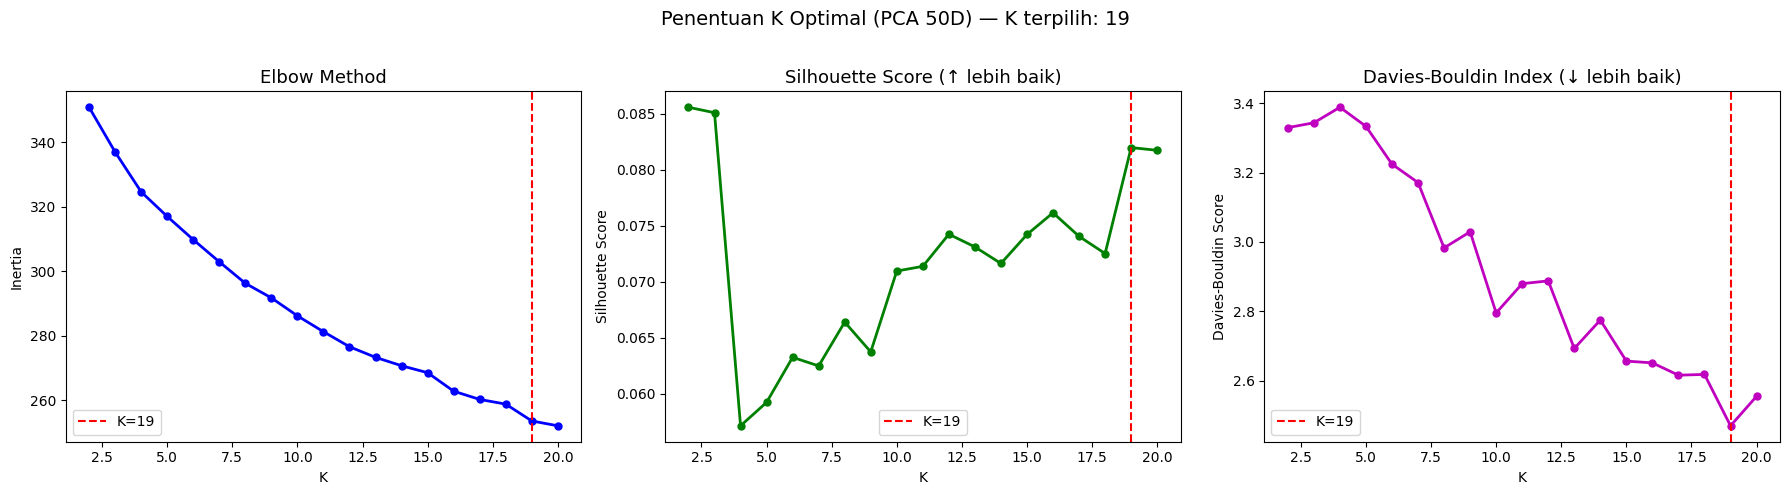

Plot disimpan ke hasil_clustering/elbow_silhouette.png


In [78]:
# Cari K optimal menggunakan Elbow + Silhouette + Davies-Bouldin
K_MIN, K_MAX = 2, 20

# K_FLOOR: batas bawah K untuk auto-selection.
# Silhouette hampir selalu puncak di K=2 untuk text embedding (fenomena umum),
# sehingga kita batasi pencarian otomatis mulai dari K=5 ke atas.
K_FLOOR = 5

# MANUAL_K: override manual. None = auto dari Davies-Bouldin terbaik (>= K_FLOOR)
MANUAL_K = None

inertias, sil_scores, db_scores = [], [], []
ks = list(range(K_MIN, K_MAX + 1))

print(f"Mencari K optimal pada {N_COMPONENTS}D PCA embeddings...")
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(embeddings_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(embeddings_pca, labels_k))
    db_scores.append(davies_bouldin_score(embeddings_pca, labels_k))
    print(f"  K={k:2d} | inertia={km.inertia_:,.0f} | silhouette={sil_scores[-1]:.4f} | davies-bouldin={db_scores[-1]:.4f}")

# Auto-select: cari Davies-Bouldin minimum hanya pada K >= K_FLOOR
ks_floor = [k for k in ks if k >= K_FLOOR]
db_floor = [db_scores[ks.index(k)] for k in ks_floor]
best_k_auto = ks_floor[int(np.argmin(db_floor))]
best_k = MANUAL_K if MANUAL_K is not None else best_k_auto

print(f"\nK terbaik otomatis (Davies-Bouldin, K>={K_FLOOR}): {best_k_auto}")
print(f"K yang digunakan                                  : {best_k}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(ks, inertias, "bo-", linewidth=2, markersize=5)
ax1.axvline(x=best_k, color="r", linestyle="--", label=f"K={best_k}")
ax1.set_title("Elbow Method", fontsize=13)
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia"); ax1.legend()

ax2.plot(ks, sil_scores, "go-", linewidth=2, markersize=5)
ax2.axvline(x=best_k, color="r", linestyle="--", label=f"K={best_k}")
ax2.set_title("Silhouette Score (↑ lebih baik)", fontsize=13)
ax2.set_xlabel("K"); ax2.set_ylabel("Silhouette Score"); ax2.legend()

ax3.plot(ks, db_scores, "mo-", linewidth=2, markersize=5)
ax3.axvline(x=best_k, color="r", linestyle="--", label=f"K={best_k}")
ax3.set_title("Davies-Bouldin Index (↓ lebih baik)", fontsize=13)
ax3.set_xlabel("K"); ax3.set_ylabel("Davies-Bouldin Score"); ax3.legend()

plt.suptitle(f"Penentuan K Optimal (PCA {N_COMPONENTS}D) — K terpilih: {best_k}", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTPUT_DIR, "elbow_silhouette.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot disimpan ke {OUTPUT_DIR}/elbow_silhouette.png")

In [79]:
print(f"Menjalankan K-Means dengan K={best_k} pada {N_COMPONENTS}D PCA embeddings...")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_pca)

df["cluster"] = cluster_labels

print("\nDistribusi cluster:")
dist = df["cluster"].value_counts().sort_index()
for cid, count in dist.items():
    print(f"  Cluster {cid}: {count} judul")

Menjalankan K-Means dengan K=19 pada 50D PCA embeddings...

Distribusi cluster:
  Cluster 0: 39 judul
  Cluster 1: 27 judul
  Cluster 2: 32 judul
  Cluster 3: 60 judul
  Cluster 4: 50 judul
  Cluster 5: 51 judul
  Cluster 6: 39 judul
  Cluster 7: 47 judul
  Cluster 8: 17 judul
  Cluster 9: 48 judul
  Cluster 10: 20 judul
  Cluster 11: 89 judul
  Cluster 12: 40 judul
  Cluster 13: 69 judul
  Cluster 14: 33 judul
  Cluster 15: 14 judul
  Cluster 16: 40 judul
  Cluster 17: 29 judul
  Cluster 18: 48 judul


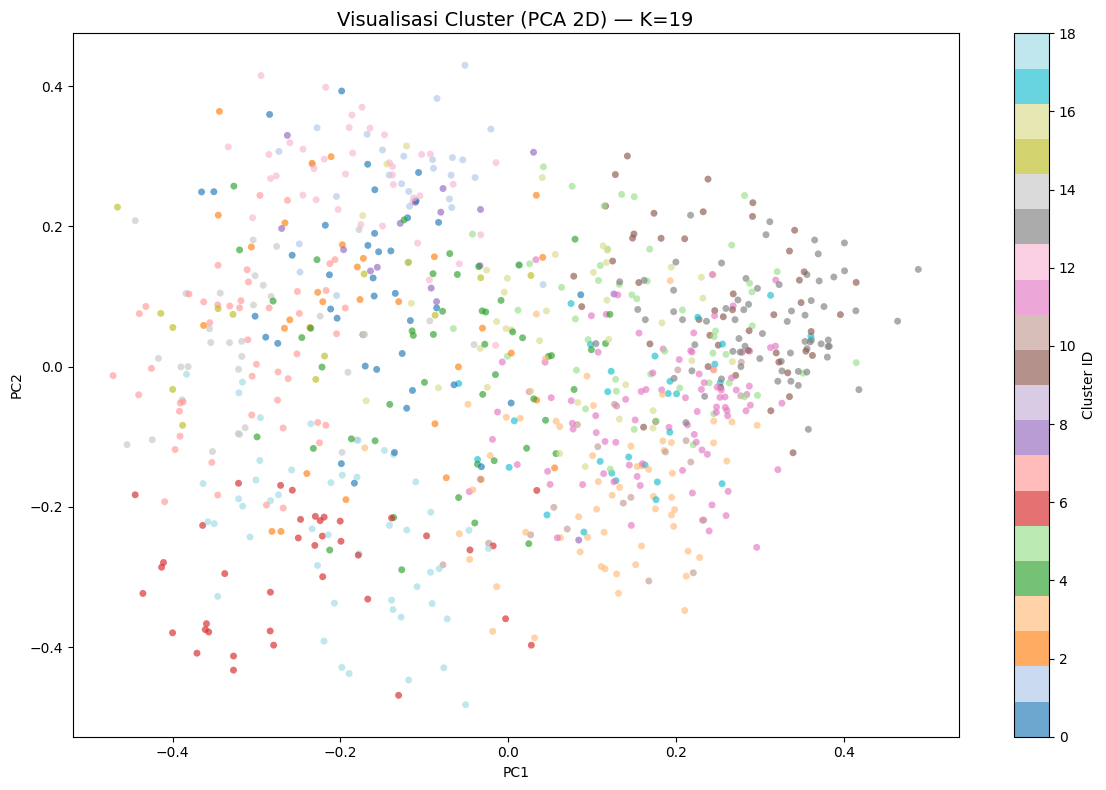

Visualisasi disimpan ke hasil_clustering/cluster_visualisasi.png


In [80]:
pca_viz = PCA(n_components=2, random_state=42)
emb_2d = pca_viz.fit_transform(embeddings_pca)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=cluster_labels, cmap="tab20",
    alpha=0.65, s=25, linewidths=0
)
plt.colorbar(scatter, label="Cluster ID")
plt.title(f"Visualisasi Cluster (PCA 2D) — K={best_k}", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_visualisasi.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Visualisasi disimpan ke {OUTPUT_DIR}/cluster_visualisasi.png")

In [81]:
result_df = df[["id", "title", "clean_title", "category", "year", "author", "advisor", "url", "abstract", "cluster"]].copy()

all_csv_path = os.path.join(OUTPUT_DIR, "hasil_clustering_all.csv")
result_df.to_csv(all_csv_path, index=False)
print(f"Semua hasil: {all_csv_path}")

print("\nFile per cluster:")
for cid in sorted(result_df["cluster"].unique()):
    cluster_df = result_df[result_df["cluster"] == cid].copy()
    out_path = os.path.join(OUTPUT_DIR, f"cluster_{cid}.csv")
    cluster_df.to_csv(out_path, index=False)
    print(f"  Cluster {cid:2d} ({len(cluster_df):4d} judul): {out_path}")

Semua hasil: hasil_clustering\hasil_clustering_all.csv

File per cluster:
  Cluster  0 (  39 judul): hasil_clustering\cluster_0.csv
  Cluster  1 (  27 judul): hasil_clustering\cluster_1.csv
  Cluster  2 (  32 judul): hasil_clustering\cluster_2.csv
  Cluster  3 (  60 judul): hasil_clustering\cluster_3.csv
  Cluster  4 (  50 judul): hasil_clustering\cluster_4.csv
  Cluster  5 (  51 judul): hasil_clustering\cluster_5.csv
  Cluster  6 (  39 judul): hasil_clustering\cluster_6.csv
  Cluster  7 (  47 judul): hasil_clustering\cluster_7.csv
  Cluster  8 (  17 judul): hasil_clustering\cluster_8.csv
  Cluster  9 (  48 judul): hasil_clustering\cluster_9.csv
  Cluster 10 (  20 judul): hasil_clustering\cluster_10.csv
  Cluster 11 (  89 judul): hasil_clustering\cluster_11.csv
  Cluster 12 (  40 judul): hasil_clustering\cluster_12.csv
  Cluster 13 (  69 judul): hasil_clustering\cluster_13.csv
  Cluster 14 (  33 judul): hasil_clustering\cluster_14.csv
  Cluster 15 (  14 judul): hasil_clustering\cluster